<a href="https://colab.research.google.com/github/EmilianoSantacruz/EmilianoSantacruz/blob/main/labs/08-clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/rhodes-byu/cs-stat-180/blob/main/labs/08-clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><p><b>After clicking the "Open in Colab" link, copy the notebook to your own Google Drive before getting started, or it will not save your work</b></p>

One of the most straightforward tasks we can perform on a data set without labels is to find groups of data in our dataset which are similar to one another -- what we call clusters.

K-Means is one of the most popular "clustering" algorithms. K-means stores k centroids that it uses to define clusters. A point is considered to be in a particular cluster if it is closer to that cluster's centroid than any other centroid.

K-Means finds the best centroids by alternating between (1) assigning data points to clusters based on the current centroids (2) chosing centroids (points which are the center of a cluster) based on the current assignment of data points to clusters.

## Dataset: MNIST

### MNIST dataset — a brief overview

**Introduction**
The MNIST (Modified National Institute of Standards and Technology) dataset is a widely used benchmark in machine learning. It contains images of handwritten digits and is often used to teach and test classification and clustering techniques.

**Description**
- Type: Handwritten digit images  
- Size: 70,000 grayscale images (28 × 28 pixels)  
  - Training set: 60,000 images  
  - Test set: 10,000 images  
- Classes: 10 (digits 0–9)  
- Format: Each example is a flattened 784-dimensional vector (28×28 pixels) or a 28×28 image with pixel values in [0, 255].  

**Why use MNIST?**
- It is commonly used as a 'toy' dataset in machine learning.
- Simple and well-structured, so students can focus on methods rather than data cleaning.
- Large enough to illustrate practical issues (scaling, dimensionality reduction, speed) but small enough to run on a laptop when sampled.

**Accessing MNIST**
Use scikit-learn's `fetch_openml` to download the MNIST dataset:

```python
        from sklearn.datasets import fetch_openml
        mnist = fetch_openml('mnist_784', version=1, parser='auto')
        X, y = mnist['data'], mnist['target']
```

Format returned by `fetch_openml('mnist_784')`:
- `X`: a table-like object with 70,000 rows and 784 columns; each row is a flattened 28×28 image (pixels ordered 0...783). Pixel values are typically in the range 0–255.  
- `y`: labels for each row (digits 0–9), often returned as strings; convert to integers with `y = y.astype(int)` if desired.  
  

Quick note: to visualize a row as an image use: `X.iloc[i].values.reshape(28,28)` (or `X.values[i].reshape(28,28)`), then display with `plt.imshow(...)`.

In [1]:
from sklearn.datasets import fetch_openml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics import adjusted_rand_score
from sklearn.decomposition import PCA
import seaborn as sns

# Set global random seed for the notebook
np.random.seed(42)

In [2]:
# Load MNIST dataset
mnist = fetch_openml('mnist_784', version = 1, parser = 'auto')
X, y = mnist['data'], mnist['target']

The MNIST digits in this set are flattened arrays of 784 pixels. We can reshape them to 28x28 pixels and plot them using matplotlib.

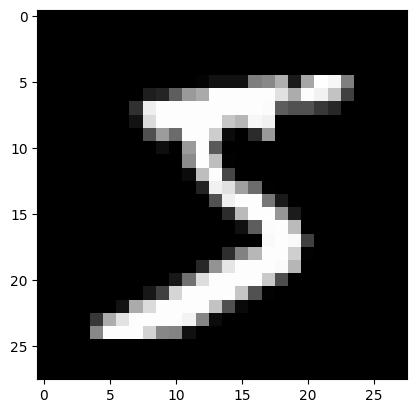

In [3]:
image = X.iloc[0, :].values.reshape((28, 28))
plt.imshow(image, cmap='gray')

### 1. Preparing the Data

a. Using the full dataset, *normalize* each image so that the minimum value is 0, and the maximum is 1. This is a standard practice for image datasets.  (Hint: the maximum pixel value is 255, the minimum is 0. How can we rescale this so the maximum is 1?)


In [4]:
X_norm = X / 255.0


print(X_norm.min().min(), X_norm.max().max())
X_norm.head()

0.0 1.0


,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


b. Get a random sample of 10% of the data. You will use this sample for the remainder of the questions to reduce computation time.

In [5]:
sample_size = int(len(X_norm) * 0.10)

sample_idx = np.random.choice(X_norm.index, size=sample_size, replace=False)

X_sample = X_norm.loc[sample_idx].reset_index(drop=True)
y_sample = y.loc[sample_idx].reset_index(drop=True)

y_sample = y_sample.astype(int)

print("X_sample shape:", X_sample.shape)
print("y_sample shape:", y_sample.shape)

X_sample shape: (7000, 784)
y_sample shape: (7000,)


### 2. Fitting k-Means

a. Using the MNIST subset, determine the optimal k value for k-means according to the WCSS elbow method. Use a range of k-values from 2 - 15. (Hint: The plot will not be cut and dry like some of the class examples; just use your best judgement!)

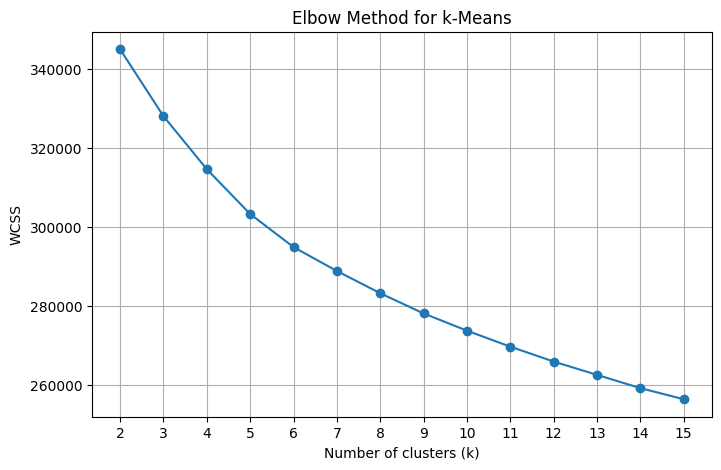

In [6]:
wcss = []
k_values = range(2, 16)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_sample)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, wcss, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for k-Means")
plt.xticks(k_values)
plt.grid(True)
plt.show()

b. Fit a k-means model with the optimal k value.

In [7]:
k_optimal = 10

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_sample)

print("Cluster labels shape:", kmeans_labels.shape)

Cluster labels shape: (7000,)


c. High-dimensional data—like MNIST digit images with 784 pixels—are hard to visualize.  
**Dimensionality reduction** helps us find a lower-dimensional view that keeps important patterns.

**Principal Component Analysis (PCA)** is a simple and fast method that finds directions of maximum variation in the data. By keeping only the top two directions, we can make a 2D version of our data that’s easy to plot.

Use **PCA** to reduce the MNIST data to **2 dimensions** (`n_components=2`).  
Then make a **scatterplot** of the 2D data and **color the points by their k-means cluster labels**. Use the Dark2 colormap to help distingish the colors. It will also be helpful to shrink the point size (e.g., s = 0.5).

**Hint:** Use [`sklearn.decomposition.PCA`](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html).


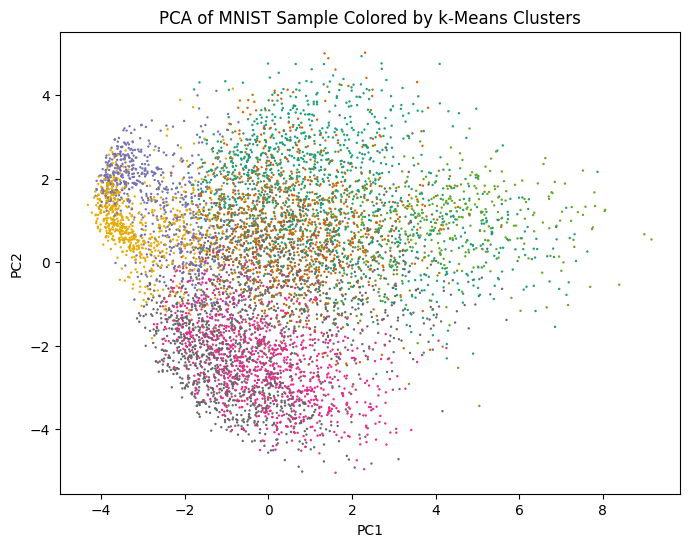

In [8]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='Dark2',
    s=0.5
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of MNIST Sample Colored by k-Means Clusters")
plt.show()

d. Create two side-by-side scatterplots using the PCA representation (first two principal components) using plt.subplots. Color the first fig according to the true labels and the second according to k-means cluster labels. Be sure to include proper figure titles and a legend.

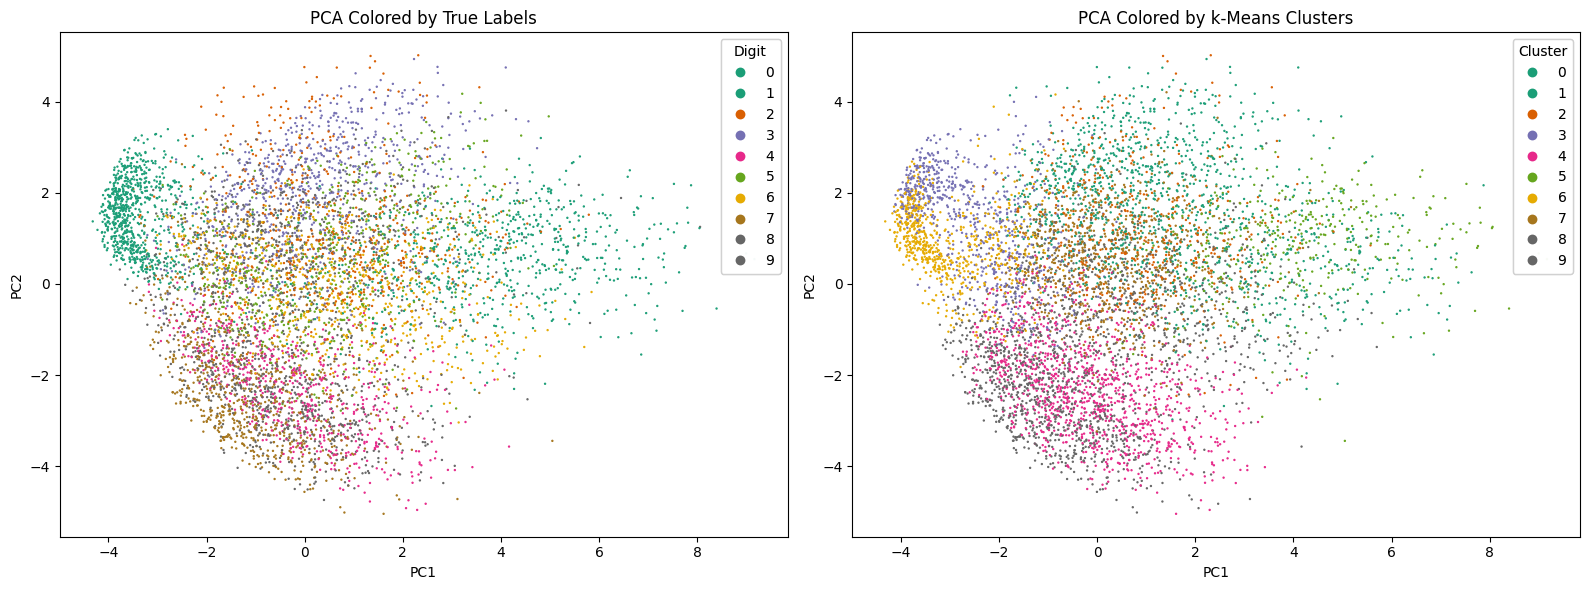

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

scatter1 = axes[0].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y_sample,
    cmap='Dark2',
    s=0.5
)
axes[0].set_title("PCA Colored by True Labels")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
legend1 = axes[0].legend(*scatter1.legend_elements(num=10), title="Digit", loc="upper right")
axes[0].add_artist(legend1)

scatter2 = axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='Dark2',
    s=0.5
)
axes[1].set_title("PCA Colored by k-Means Clusters")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
legend2 = axes[1].legend(*scatter2.legend_elements(), title="Cluster", loc="upper right")
axes[1].add_artist(legend2)

plt.tight_layout()
plt.show()

e. Describe the fit. Does this align with your expectation? (Note: The specific color used for the clusters and labels will not align, but do you see some of the same patterns emerge?)

The fit is decent but not perfect. Some groups in the k-means plot look similar to the true-label groups, so a few real patterns do appear. However, there is still overlap between clusters, which is expected because handwritten digits can look very similar. This mostly matches my expectation.

f. Display the cluster centroids as images in a grid using subplots. What digits do they most resemble?

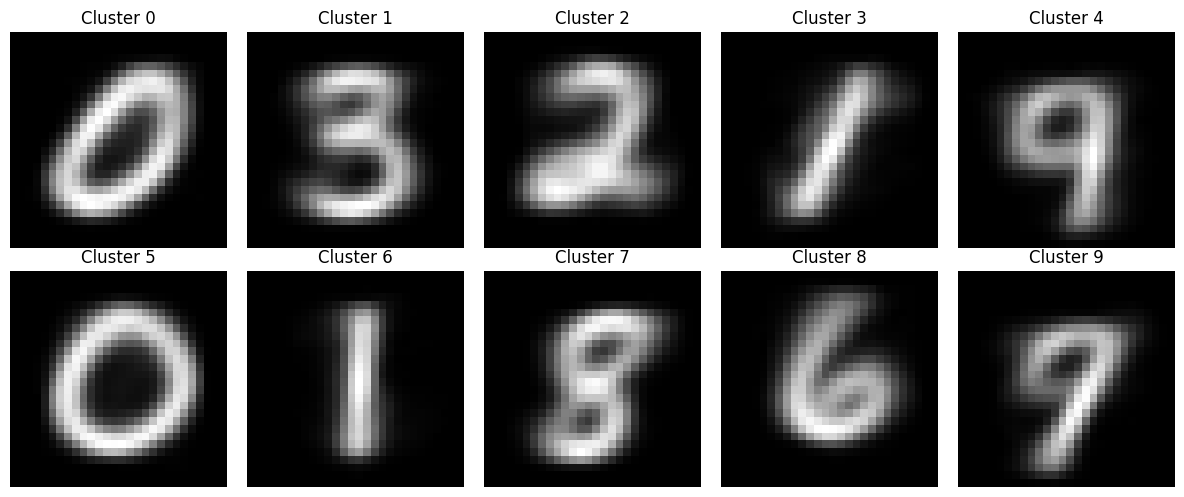

In [10]:
centroids = kmeans.cluster_centers_

rows = 2
cols = int(np.ceil(k_optimal / rows))

fig, axes = plt.subplots(rows, cols, figsize=(12, 5))

for i, ax in enumerate(axes.flat):
    if i < k_optimal:
        centroid_image = centroids[i].reshape(28, 28)
        ax.imshow(centroid_image, cmap='gray')
        ax.set_title(f"Cluster {i}")
        ax.axis('off')
    else:
        ax.axis('off')

plt.tight_layout()
plt.show()

### 3. Hierarchical Clustering
Here you will be performing hierarchical clustering on a smaller data subset.

Here you will be comparing linkage methods and metrics. Use the following linkage/metric combinations:

| Linkage Method | Metrics              |
|---------------|----------------------|
| Ward         | Euclidean            |
| Complete     | Euclidean, Cosine |

a. Get a subset of 10% of your original subset (you should have 700 points).

In [11]:
hc_size = int(len(X_sample) * 0.10)

hc_idx = np.random.choice(np.arange(len(X_sample)), size=hc_size, replace=False)

X_hc = X_sample.iloc[hc_idx].reset_index(drop=True)
y_hc = y_sample.iloc[hc_idx].reset_index(drop=True)

print("X_hc shape:", X_hc.shape)
print("y_hc shape:", y_hc.shape)

X_hc shape: (700, 784)
y_hc shape: (700,)


b. Fit hierarhiccal clustering with 10 clusters for each combination and store the silhouette scores.

In [12]:
results = []

hc_ward = AgglomerativeClustering(n_clusters=10, linkage='ward')
labels_ward = hc_ward.fit_predict(X_hc)
score_ward = silhouette_score(X_hc, labels_ward, metric='euclidean')
results.append(("ward", "euclidean", score_ward))

hc_complete_euclidean = AgglomerativeClustering(
    n_clusters=10,
    linkage='complete',
    metric='euclidean'
)
labels_complete_euclidean = hc_complete_euclidean.fit_predict(X_hc)
score_complete_euclidean = silhouette_score(X_hc, labels_complete_euclidean, metric='euclidean')
results.append(("complete", "euclidean", score_complete_euclidean))

hc_complete_cosine = AgglomerativeClustering(
    n_clusters=10,
    linkage='complete',
    metric='cosine'
)
labels_complete_cosine = hc_complete_cosine.fit_predict(X_hc)
score_complete_cosine = silhouette_score(X_hc, labels_complete_cosine, metric='cosine')
results.append(("complete", "cosine", score_complete_cosine))

results_df = pd.DataFrame(results, columns=["Linkage", "Metric", "Silhouette Score"])
results_df

,Linkage,Metric,Silhouette Score
0,ward,euclidean,0.050420
1,complete,euclidean,0.053404
2,complete,cosine,0.065302


c. According to the silhouette scores, which combination is best?

In [13]:
best_model = results_df.sort_values(by="Silhouette Score", ascending=False).iloc[0]
best_model

,2
Linkage,complete
Metric,cosine
Silhouette Score,0.065302


### 4. Visualizing Clustered Digits

a. Pick one of the cluster labels from your best models (k-means or HC). Select a random subset of 20 points belonging to that cluster.  

In [14]:
chosen_cluster = 0

cluster_indices = np.where(kmeans_labels == chosen_cluster)[0]

selected_indices = np.random.choice(cluster_indices, size=20, replace=False)

X_cluster_20 = X_sample.iloc[selected_indices]
y_cluster_20 = y_sample.iloc[selected_indices]

print("Chosen cluster:", chosen_cluster)
print("Selected 20 points.")

Chosen cluster: 0
Selected 20 points.


b. Using subplots (4 rows, 5 columns), plot the 20 digit images.  

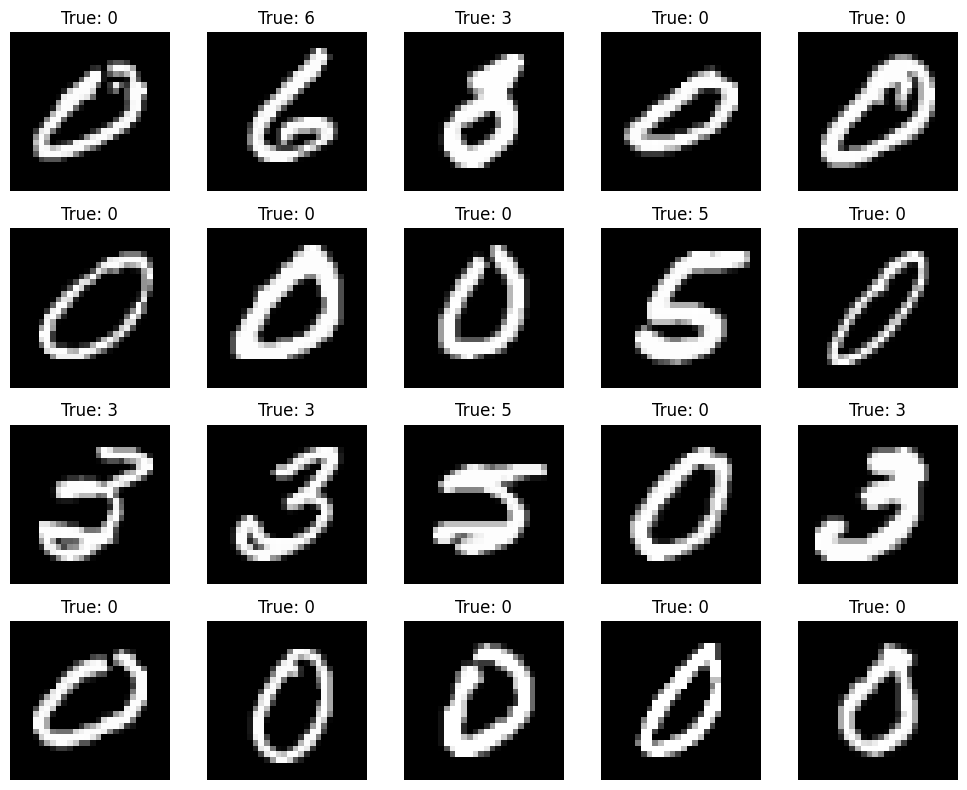

In [15]:
fig, axes = plt.subplots(4, 5, figsize=(10, 8))

for i, ax in enumerate(axes.flat):
    image = X_cluster_20.iloc[i].values.reshape(28, 28)
    ax.imshow(image, cmap='gray')
    ax.set_title(f"True: {y_cluster_20.iloc[i]}")
    ax.axis('off')

plt.tight_layout()
plt.show()

c. Comment on the clustered points (e.g., do they look similar?, are the representing the same digit?, etc.)

Most of the images in this cluster look similar in shape and writing style. Several of them appear to represent the same digit, although a few may look slightly different because handwriting varies from person to person. Overall, the cluster seems reasonably consistent.